In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
from mlxtend.plotting import plot_decision_regions
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, confusion_matrix, r2_score, mean_squared_error, classification_report, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import statistics
# Configuración matplotlib
# ==============================================================================
plt.rcParams['image.cmap'] = "bwr"
#plt.rcParams['figure.dpi'] = "100"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


**1. Cargue los datos en Python usando Pandas y muestre los primeros 10 registros.**

In [ ]:
datos=pd.read_csv('insurance_claims.csv')

In [ ]:
datos.head(10)

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,521585,17/10/2014,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y
1,228,42,342868,27/06/2006,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,Y
2,134,29,687698,06/09/2000,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N
3,256,41,227811,25/05/1990,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y
4,228,44,367455,06/06/2014,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,N
5,256,39,104594,12/10/2006,OH,250/500,1000,1351.10,0,478456,...,2,NO,64100,6410,6410,51280,Saab,95,2003,Y
6,137,34,413978,04/06/2000,IN,250/500,1000,1333.35,0,441716,...,0,?,78650,21450,7150,50050,Nissan,Pathfinder,2012,N
7,165,37,429027,03/02/1990,IL,100/300,1000,1137.03,0,603195,...,2,YES,51590,9380,9380,32830,Audi,A5,2015,N
8,27,33,485665,05/02/1997,IL,100/300,500,1442.99,0,601734,...,1,YES,27700,2770,2770,22160,Toyota,Camry,2012,N
9,212,42,636550,25/07/2011,IL,100/300,500,1315.68,0,600983,...,1,?,42300,4700,4700,32900,Saab,92x,1996,N


**2. Remplace ‘?’ por np.NaN y verifique si hay valores nulos con el siguiente código:**

In [ ]:
datos = datos.replace('?', np.NaN)
datos.isnull().any()

months_as_customer             False
age                            False
policy_number                  False
policy_bind_date               False
policy_state                   False
policy_csl                     False
policy_deductable              False
policy_annual_premium          False
umbrella_limit                 False
insured_zip                    False
insured_sex                    False
insured_education_level        False
insured_occupation             False
insured_hobbies                False
insured_relationship           False
capital-gains                  False
capital-loss                   False
incident_date                  False
incident_type                  False
collision_type                  True
incident_severity              False
authorities_contacted          False
incident_state                 False
incident_city                  False
incident_location              False
incident_hour_of_the_day       False
number_of_vehicles_involved    False
p

**3. Remplace los valores faltantes de collision_type por la moda y los de las otras dos
columnas por 'NO'.**

In [ ]:
datos['collision_type'].fillna(datos['collision_type'].mode()[0], inplace=True)

In [ ]:
datos['collision_type'].isna().sum()

0

In [ ]:
datos['collision_type']

0       Side Collision
1       Rear Collision
2       Rear Collision
3      Front Collision
4       Rear Collision
            ...       
995    Front Collision
996     Rear Collision
997     Side Collision
998     Rear Collision
999     Rear Collision
Name: collision_type, Length: 1000, dtype: object

In [ ]:
datos['property_damage'] = datos['property_damage'].fillna('NO')
datos['police_report_available'] = datos['police_report_available'].fillna('NO')

In [ ]:
print(datos['property_damage'].isna().sum())
print(datos['police_report_available'].isna().sum())

0
0


In [ ]:
datos['property_damage']

0      YES
1       NO
2       NO
3       NO
4       NO
      ... 
995    YES
996    YES
997     NO
998     NO
999     NO
Name: property_damage, Length: 1000, dtype: object

In [ ]:
datos['police_report_available']

0      YES
1       NO
2       NO
3       NO
4       NO
      ... 
995     NO
996     NO
997    YES
998    YES
999     NO
Name: police_report_available, Length: 1000, dtype: object

**4. Muestre las dimensiones del dataframe (data.shape) y el tipo de las columnas
(data.info())**

In [ ]:
print('Dimensiones del dataframe ',datos.shape)

Dimensiones del dataframe  (1000, 39)


In [ ]:
print('Informacion del dataframe ',datos.info)

Informacion del dataframe  <bound method DataFrame.info of      months_as_customer  age  policy_number policy_bind_date policy_state  \
0                   328   48         521585       17/10/2014           OH   
1                   228   42         342868       27/06/2006           IN   
2                   134   29         687698       06/09/2000           OH   
3                   256   41         227811       25/05/1990           IL   
4                   228   44         367455       06/06/2014           IL   
..                  ...  ...            ...              ...          ...   
995                   3   38         941851       16/07/1991           OH   
996                 285   41         186934       05/01/2014           IL   
997                 130   34         918516       17/02/2003           OH   
998                 458   62         533940       18/11/2011           IL   
999                 456   60         556080       11/11/1996           OH   

    policy_csl  

**5. Muestre los valores estadísticos básicos de todas las columnas (contador, media,
desviación estándar, valor mínimo, valor máximo y los cuartiles).**

In [ ]:
datos.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000


**6. Muestre el mapa de calor de la matriz de correlación y su formato tidy.**

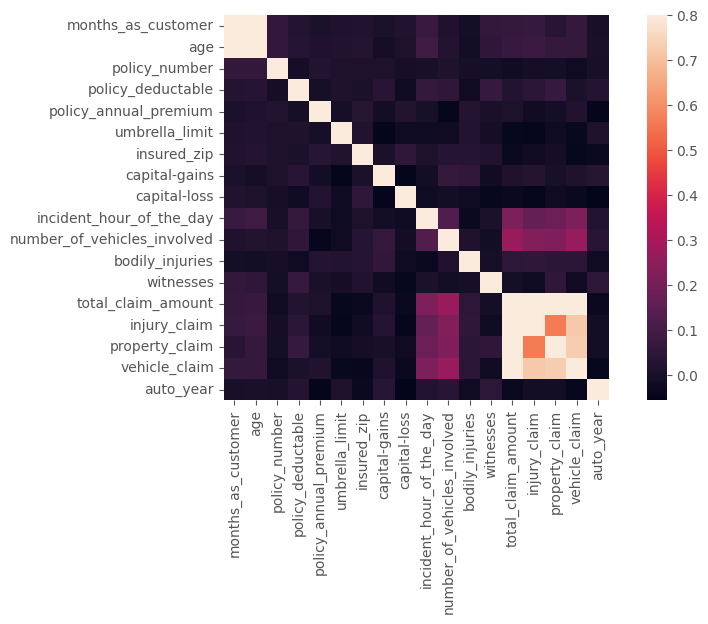

In [ ]:
corrmat = datos.corr()
f, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(corrmat, vmax=.8, square=True);

**7. Elimine las columnas que están altamente correlacionadas (>0.7) ignorando la
variable objetivo: fraud_reported.**

In [ ]:
corr = datos.corr()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(np.bool_))
drop = [column for column in upper.columns if any(np.abs(upper[column]) > 0.7)]
print(f"columns dropped are: {drop}")
datos.drop(columns=drop, axis=1, inplace=True)


columns dropped are: ['age', 'injury_claim', 'property_claim', 'vehicle_claim']


**8. Elimine las columnas de alta cardinalidad excepto las siguientes columnas:<br>
• insured_education_level<br>
• insured_occupation<br>
• insured_hobbies<br>
• insured_relationship<br>
• incident_date<br>
• incident_city<br>
• auto_make<br>**

In [ ]:
cat_cols = datos.select_dtypes('object').columns
k = 0
cardinality_cols = []



for col in cat_cols:
    value_counts = datos[col].value_counts(normalize=True).round(2)
    if len(value_counts) > 5 or len(value_counts) < 2:
        cardinality_cols.append(col)
    else:
        print("====================================================================")
        print(col)
        print(value_counts)

cardinality_cols.remove('insured_education_level')
cardinality_cols.remove('insured_occupation')
cardinality_cols.remove('insured_hobbies')
cardinality_cols.remove('insured_relationship')
cardinality_cols.remove('incident_date')
cardinality_cols.remove('incident_city')
cardinality_cols.remove('auto_make')
print(f"Removed Columns: {cardinality_cols}")
datos.drop(columns=cardinality_cols, axis=1, inplace=True)


policy_state
OH    0.35
IL    0.34
IN    0.31
Name: policy_state, dtype: float64
policy_csl
250/500     0.35
100/300     0.35
500/1000    0.30
Name: policy_csl, dtype: float64
insured_sex
FEMALE    0.54
MALE      0.46
Name: insured_sex, dtype: float64
incident_type
Multi-vehicle Collision     0.42
Single Vehicle Collision    0.40
Vehicle Theft               0.09
Parked Car                  0.08
Name: incident_type, dtype: float64
collision_type
Rear Collision     0.47
Side Collision     0.28
Front Collision    0.25
Name: collision_type, dtype: float64
incident_severity
Minor Damage      0.35
Total Loss        0.28
Major Damage      0.28
Trivial Damage    0.09
Name: incident_severity, dtype: float64
authorities_contacted
Police       0.29
Fire         0.22
Other        0.20
Ambulance    0.20
None         0.09
Name: authorities_contacted, dtype: float64
property_damage
NO     0.7
YES    0.3
Name: property_damage, dtype: float64
police_report_available
NO     0.69
YES    0.31
Name: police

**9. Elimine las columnas de varianza baja (ninguna, pero realice la prueba).**

In [ ]:
num_cols = datos.select_dtypes('number').columns

low_var_cols = []
for col in num_cols:
    scaled = (datos[col] - datos[col].mean()) / datos[col].std()
    variance = scaled.var().round(4)
    if variance == 0 or datos[col].std() == 0:
        low_var_cols.append(col)
#     else:
#         print(col, variance)

datos.drop(columns=low_var_cols, axis=1, inplace=True)
print(f"Removed Columns: {low_var_cols}")
print(datos.shape, len(low_var_cols))

Removed Columns: []
(1000, 31) 0


In [ ]:
datos

,months_as_customer,policy_number,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,...,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,auto_make,auto_year,fraud_reported
0,328,521585,OH,250/500,1000,1406.91,0,466132,MALE,MD,...,5,1,YES,1,2,YES,71610,Saab,2004,Y
1,228,342868,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,...,8,1,NO,0,0,NO,5070,Mercedes,2007,Y
2,134,687698,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,...,7,3,NO,2,3,NO,34650,Dodge,2007,N
3,256,227811,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,...,5,1,NO,1,2,NO,63400,Chevrolet,2014,Y
4,228,367455,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,...,20,1,NO,0,1,NO,6500,Accura,2009,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,941851,OH,500/1000,1000,1310.80,0,431289,FEMALE,Masters,...,20,1,YES,0,1,NO,87200,Honda,2006,N
996,285,186934,IL,100/300,1000,1436.79,0,608177,FEMALE,PhD,...,23,1,YES,2,3,NO,108480,Volkswagen,2015,N
997,130,918516,OH,250/500,500,1383.49,3000000,442797,FEMALE,Masters,...,4,3,NO,2,3,YES,67500,Suburu,1996,N
998,458,533940,IL,500/1000,2000,1356.92,5000000,441714,MALE,Associate,...,2,1,NO,0,1,YES,46980,Audi,1998,N


**10.Elimine la columna policy_number porque los identificadores no son de utilidad en
los modelos de machine learning.**

In [ ]:
datos.drop('policy_number', axis=1)

,months_as_customer,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,...,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,auto_make,auto_year,fraud_reported
0,328,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,...,5,1,YES,1,2,YES,71610,Saab,2004,Y
1,228,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,...,8,1,NO,0,0,NO,5070,Mercedes,2007,Y
2,134,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,...,7,3,NO,2,3,NO,34650,Dodge,2007,N
3,256,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,...,5,1,NO,1,2,NO,63400,Chevrolet,2014,Y
4,228,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,...,20,1,NO,0,1,NO,6500,Accura,2009,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,OH,500/1000,1000,1310.80,0,431289,FEMALE,Masters,craft-repair,...,20,1,YES,0,1,NO,87200,Honda,2006,N
996,285,IL,100/300,1000,1436.79,0,608177,FEMALE,PhD,prof-specialty,...,23,1,YES,2,3,NO,108480,Volkswagen,2015,N
997,130,OH,250/500,500,1383.49,3000000,442797,FEMALE,Masters,armed-forces,...,4,3,NO,2,3,YES,67500,Suburu,1996,N
998,458,IL,500/1000,2000,1356.92,5000000,441714,MALE,Associate,handlers-cleaners,...,2,1,NO,0,1,YES,46980,Audi,1998,N


**11.Con el siguiente código genere el grafico de dispersión entre las columnas
total_claim_amount y policy_annual_premium:**

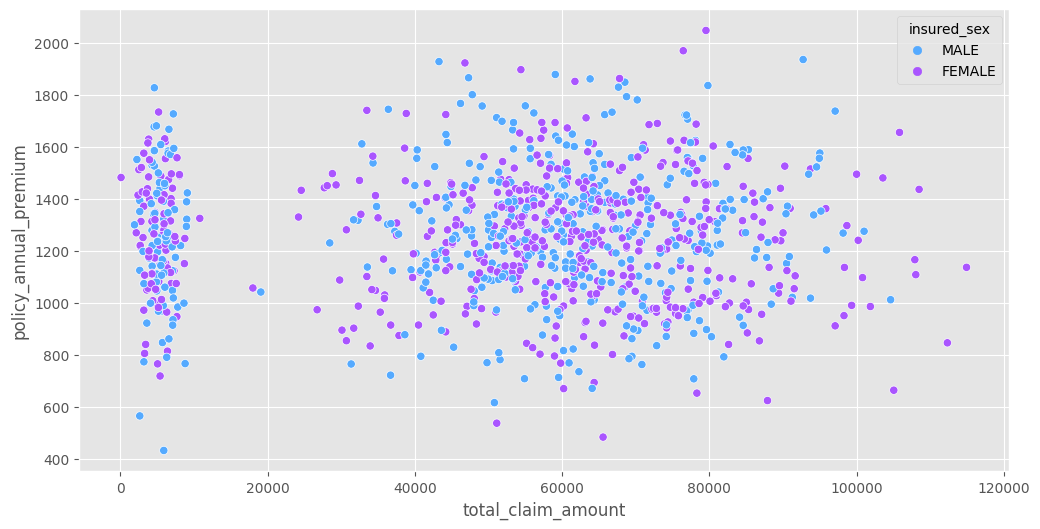

In [ ]:
f,ax=plt.subplots(1, 1, figsize=(12, 6))
ax = sns.scatterplot(x='total_claim_amount',y='policy_annual_premium',hue='insured_sex', data=datos, palette='cool')

**12.Genere el grafico de barras de la variable objetivo:**

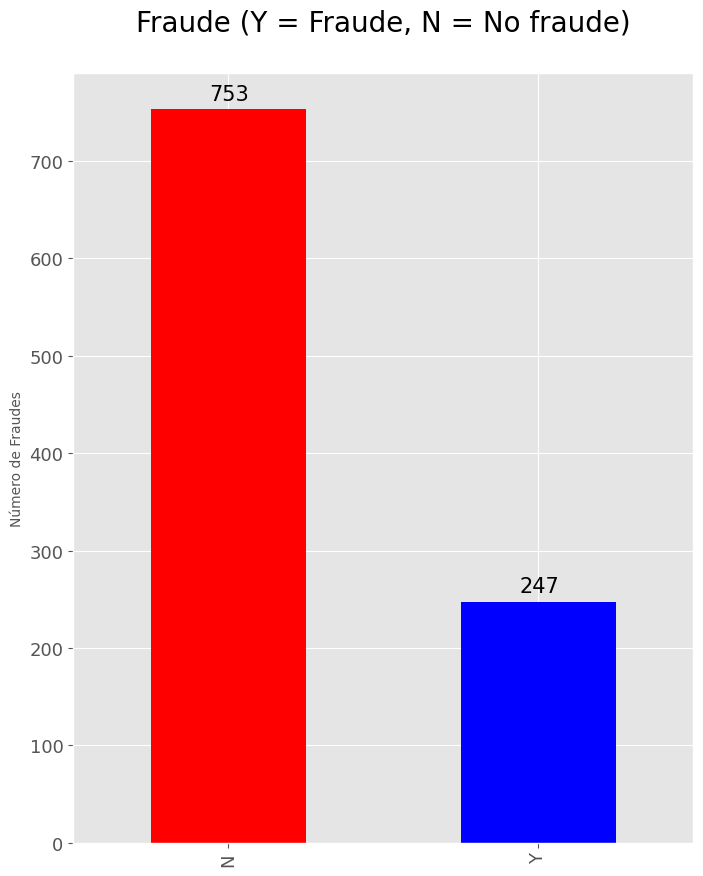

In [ ]:
ax = datos['fraud_reported'].value_counts().plot(kind='bar', figsize=(8, 10),
fontsize=13, color=["red","blue"])
ax.set_title('Fraude (Y = Fraude, N = No fraude)', size=20, pad=30)
ax.set_ylabel('Número de Fraudes', fontsize=10)
for i in ax.patches:
 ax.text(i.get_x() + 0.19, i.get_height() + 10, str(round(i.get_height(), 2)),
fontsize=15)

**13.Genere el grafico boxenplot de la relación entre incident_type y
total_claim_amount:**

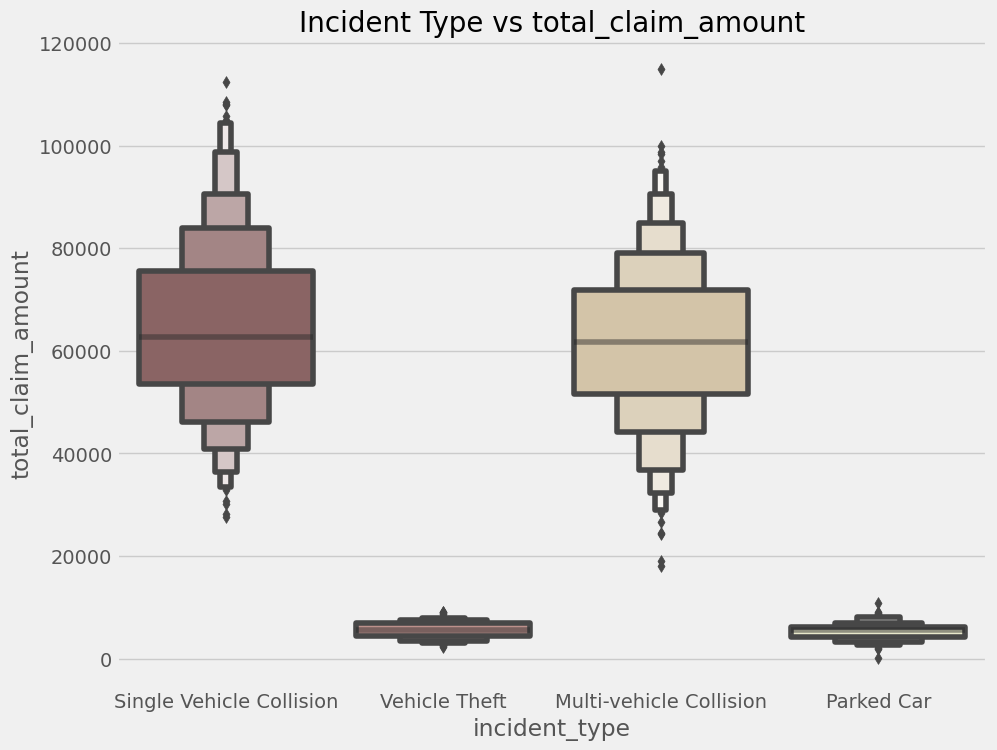

In [ ]:
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (10, 8)
sns.boxenplot(x=datos['incident_type'], y=datos['total_claim_amount'], palette =
'pink')
plt.title('Incident Type vs total_claim_amount', fontsize = 20)
plt.show()

**14.Con el siguiente código genere el grafico de tabulación cruzada entre las columnas
incident_city e incident_type:**

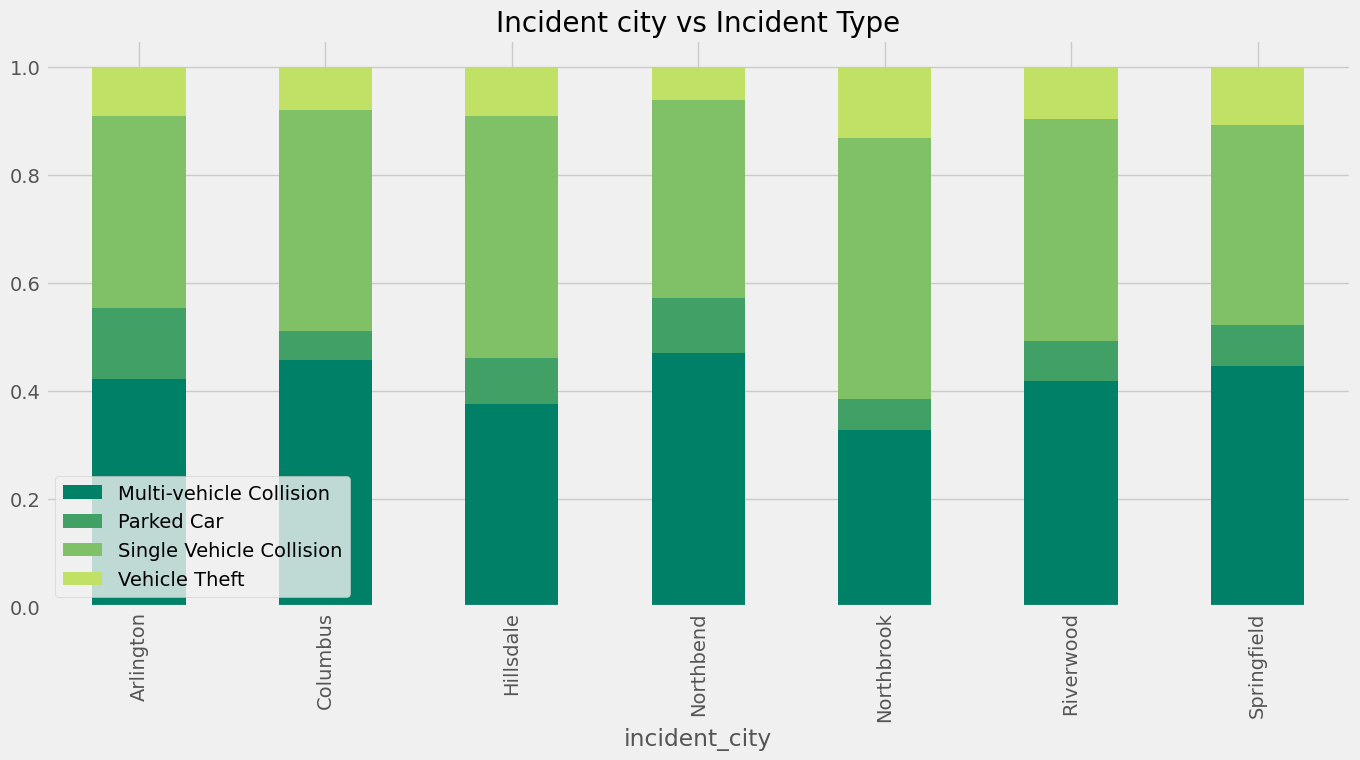

In [ ]:
incident = pd.crosstab(datos['incident_city'], datos['incident_type'])
colors = plt.cm.summer(np.linspace(0, 1, 5))
incident.div(incident.sum(1).astype(float), axis = 0).plot(kind = 'bar',
 stacked = True,
figsize = (15, 7),
color = colors)
plt.title('Incident city vs Incident Type', fontsize = 20)
plt.legend()
plt.show()

**15.Genere los gráficos de tabulación cruzada entre las siguientes columnas:<br>
• incident_type e incident_severity<br>
• incident_type y collision_type<br>
• insured_occupation y fraud_reported<br>
• insured_hobbies y fraud_reported<br>
• insured_education_level y fraud_reported<br>
Pruebe con alguno de los siguientes valores:<br>
• Paletas de colores: plt.cm.Blues, plt.cm.summer, plt.cm.inferno
• stacked = True,False**

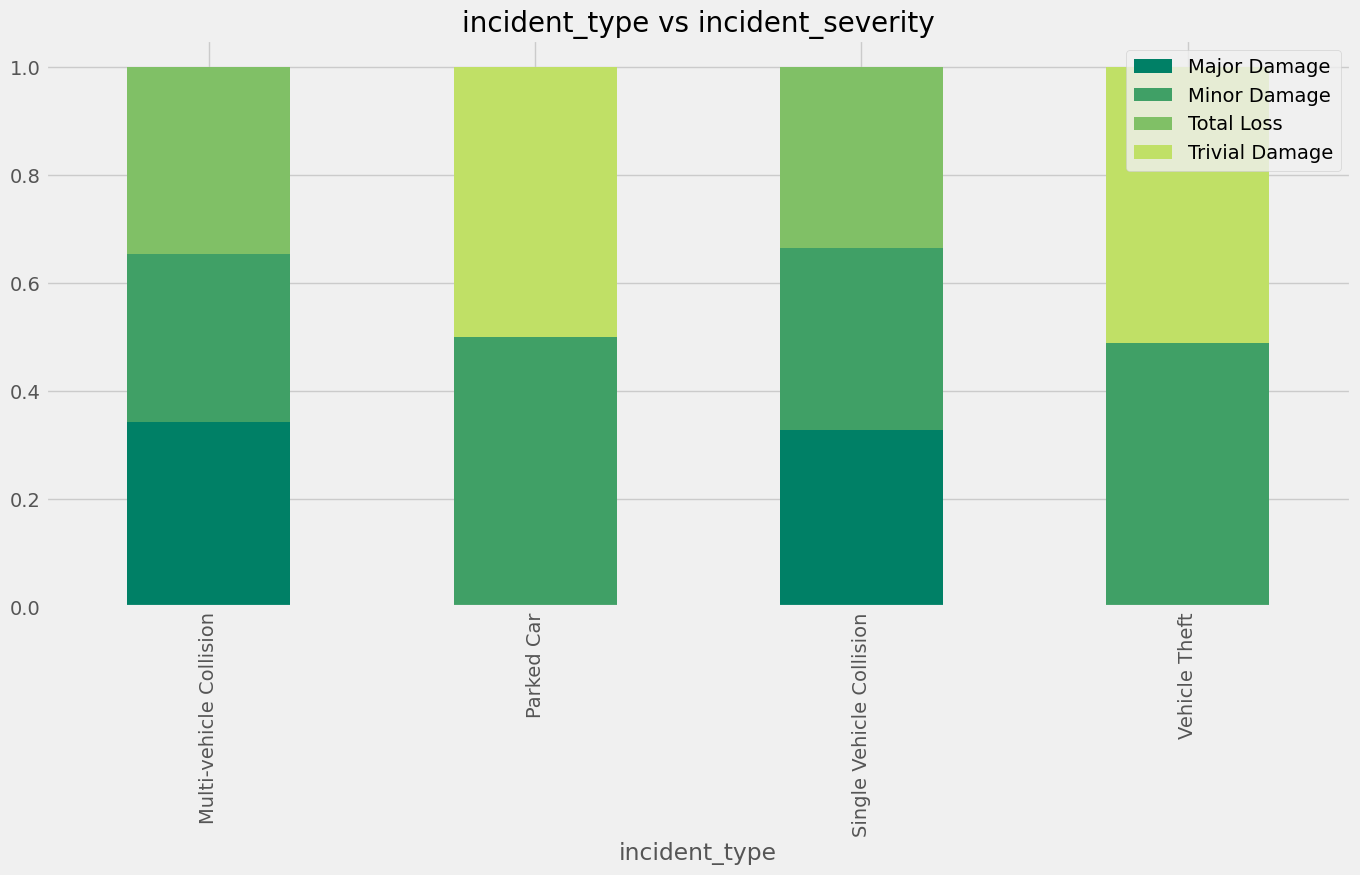

In [ ]:
#incident_type e incident_severity
incident = pd.crosstab(datos['incident_type'], datos['incident_severity'])
colors = plt.cm.summer(np.linspace(0, 1, 5))
incident.div(incident.sum(1).astype(float), axis = 0).plot(kind = 'bar',
 stacked = True,
figsize = (15, 7),
color = colors)
plt.title('incident_type vs incident_severity', fontsize = 20)
plt.legend()
plt.show()

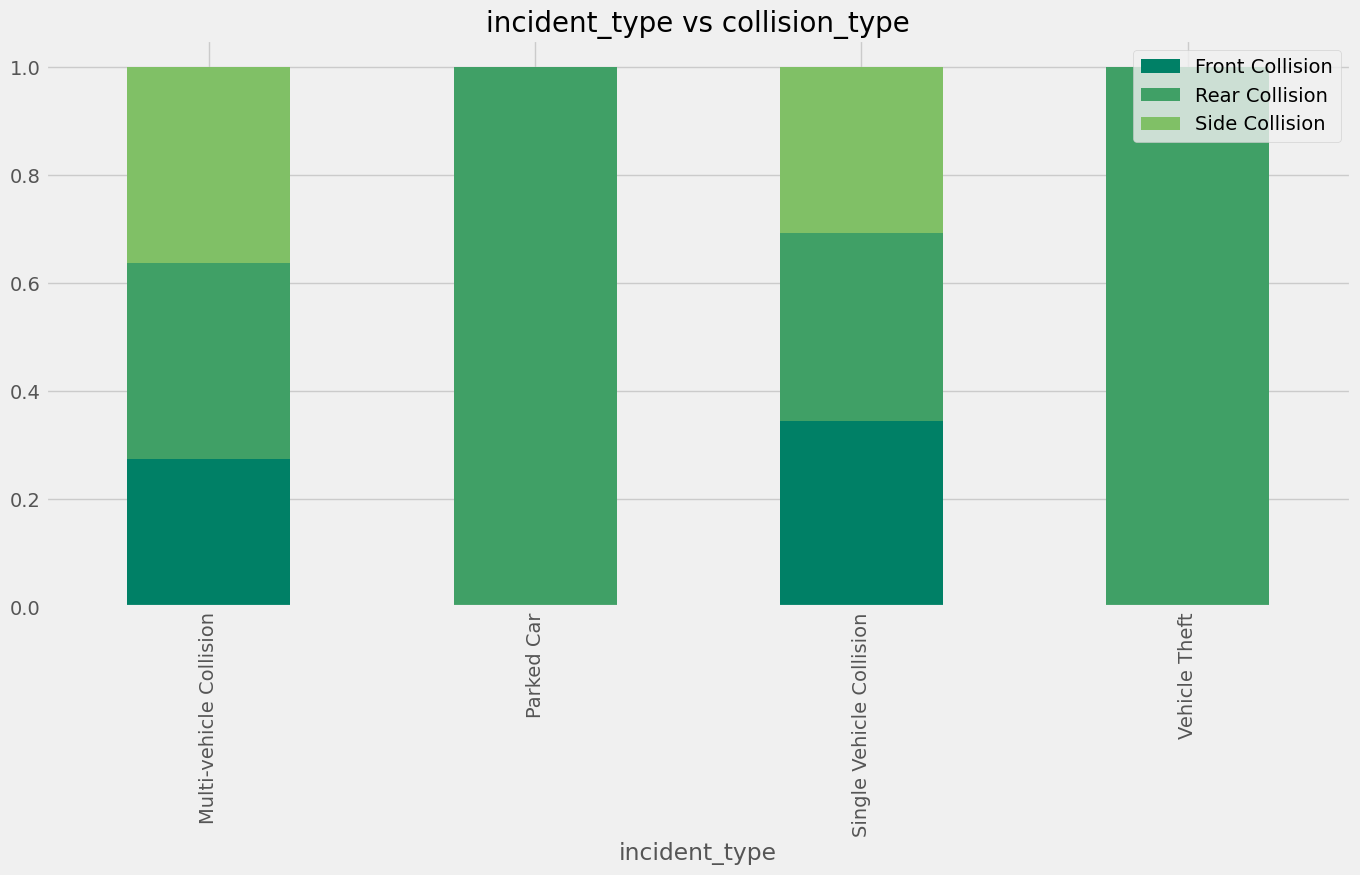

In [ ]:
#incident_type y collision_type
incident = pd.crosstab(datos['incident_type'], datos['collision_type'])
colors = plt.cm.summer(np.linspace(0, 1, 5))
incident.div(incident.sum(1).astype(float), axis = 0).plot(kind = 'bar',
 stacked = True,
figsize = (15, 7),
color = colors)
plt.title('incident_type vs collision_type', fontsize = 20)
plt.legend()
plt.show()

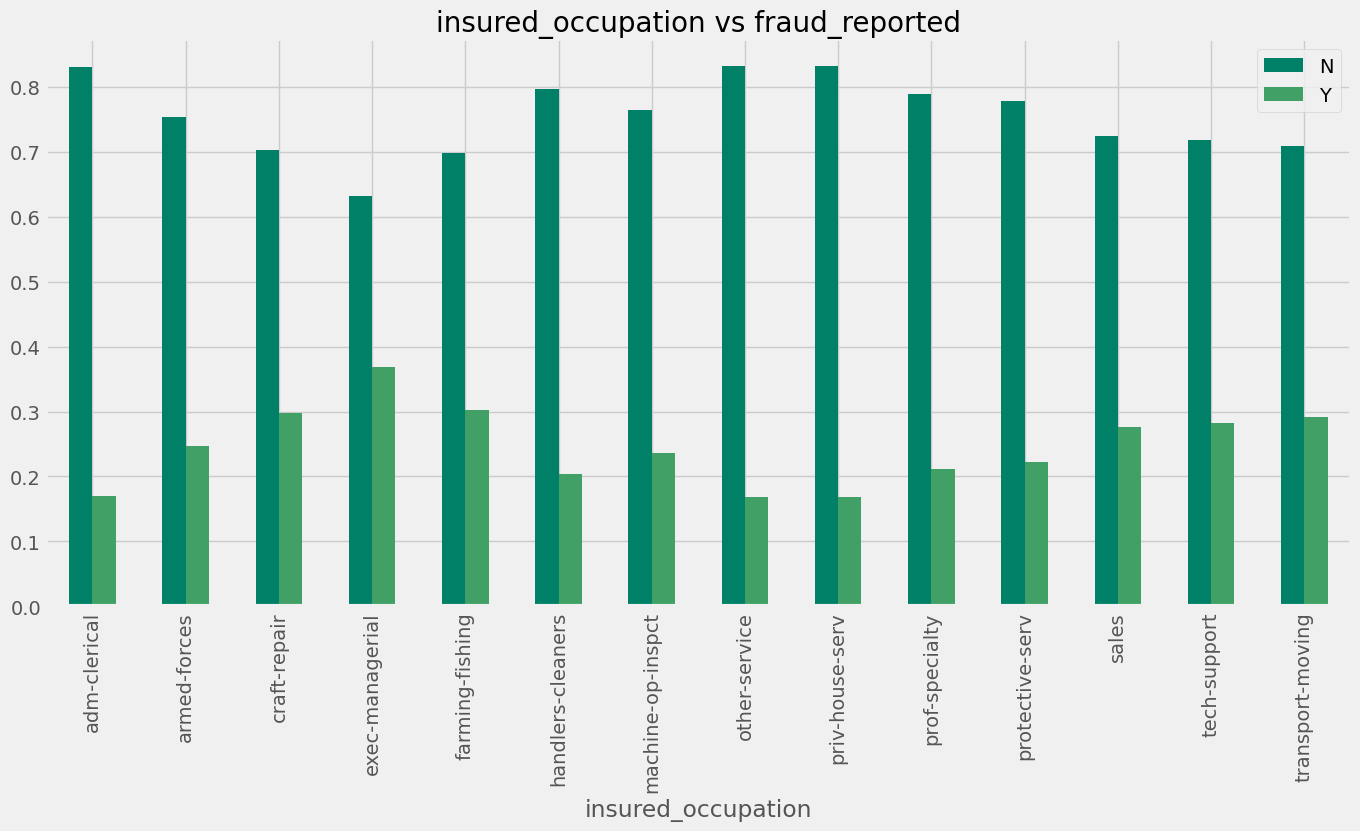

In [ ]:
#insured_occupation y fraud_reported

incident = pd.crosstab(datos['insured_occupation'], datos['fraud_reported'])
colors = plt.cm.summer(np.linspace(0, 1, 5))
incident.div(incident.sum(1).astype(float), axis = 0).plot(kind = 'bar',
 stacked = False,
figsize = (15, 7),
color = colors)
plt.title('insured_occupation vs fraud_reported', fontsize = 20)
plt.legend()
plt.show()

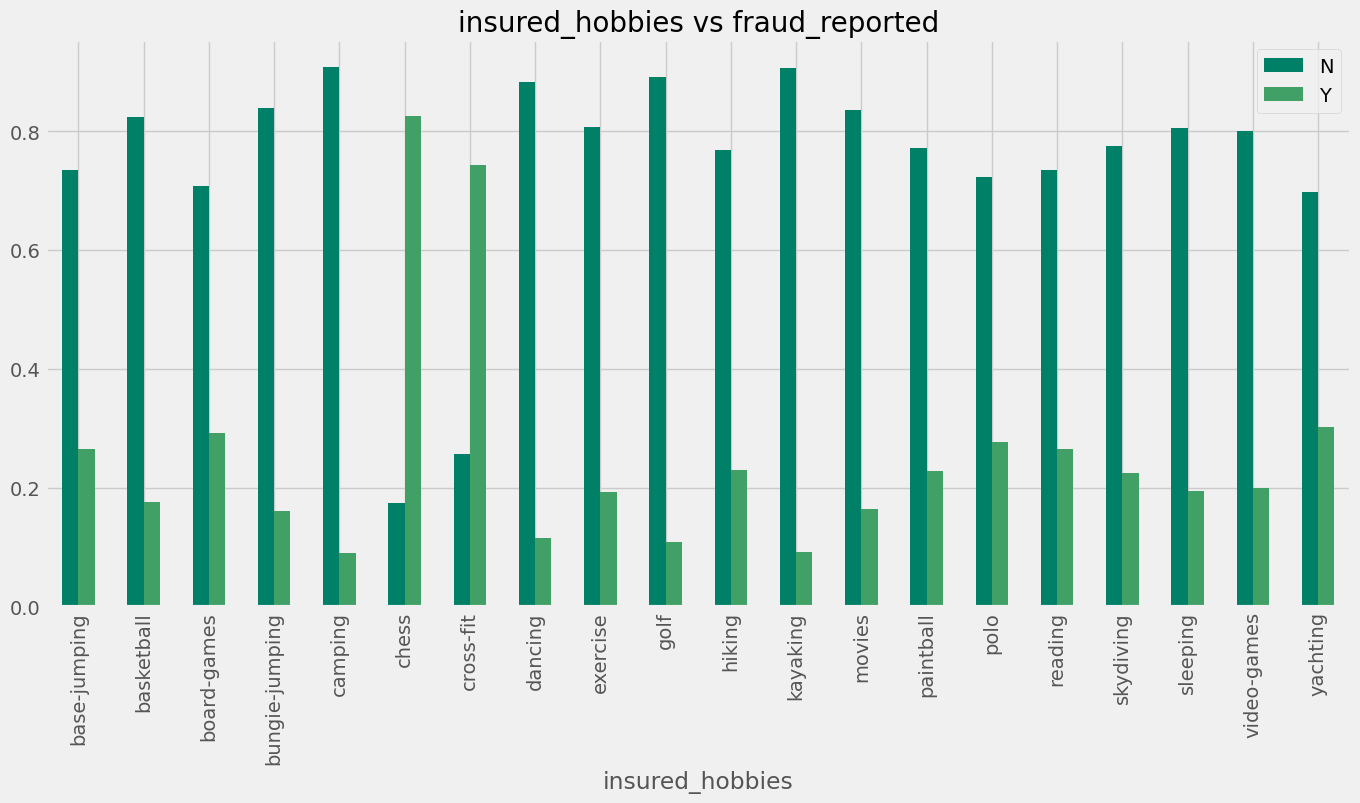

In [ ]:
#insured_hobbies y fraud_reported

incident = pd.crosstab(datos['insured_hobbies'], datos['fraud_reported'])
colors = plt.cm.summer(np.linspace(0, 1, 5))
incident.div(incident.sum(1).astype(float), axis = 0).plot(kind = 'bar',
 stacked = False,
figsize = (15, 7),
color = colors)
plt.title('insured_hobbies vs fraud_reported', fontsize = 20)
plt.legend()
plt.show()

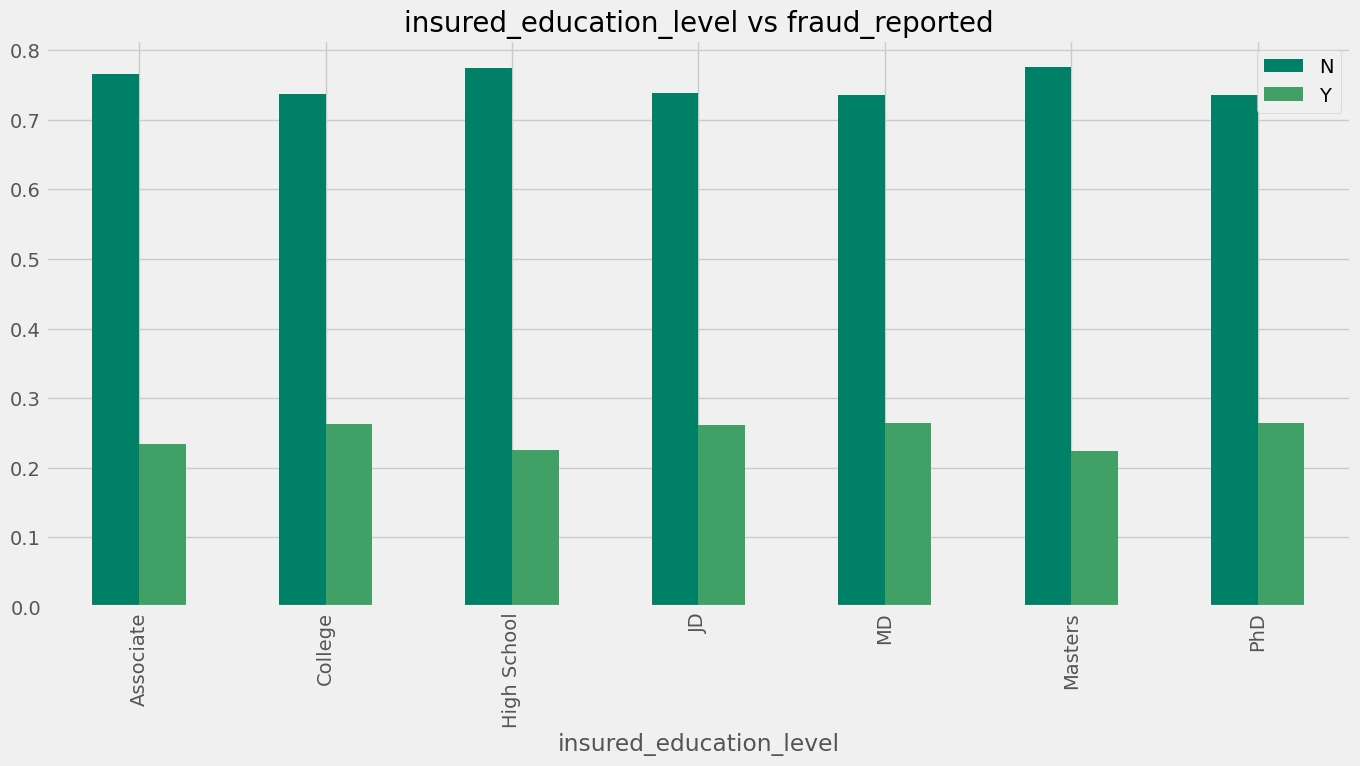

In [ ]:
#insured_education_level y fraud_reported

incident = pd.crosstab(datos['insured_education_level'], datos['fraud_reported'])
colors = plt.cm.summer(np.linspace(0, 1, 5))
incident.div(incident.sum(1).astype(float), axis = 0).plot(kind = 'bar',
 stacked = False,
figsize = (15, 7),
color = colors)
plt.title('insured_education_level vs fraud_reported', fontsize = 20)
plt.legend()
plt.show()

**16.Realice el siguiente grafico de distribución:**

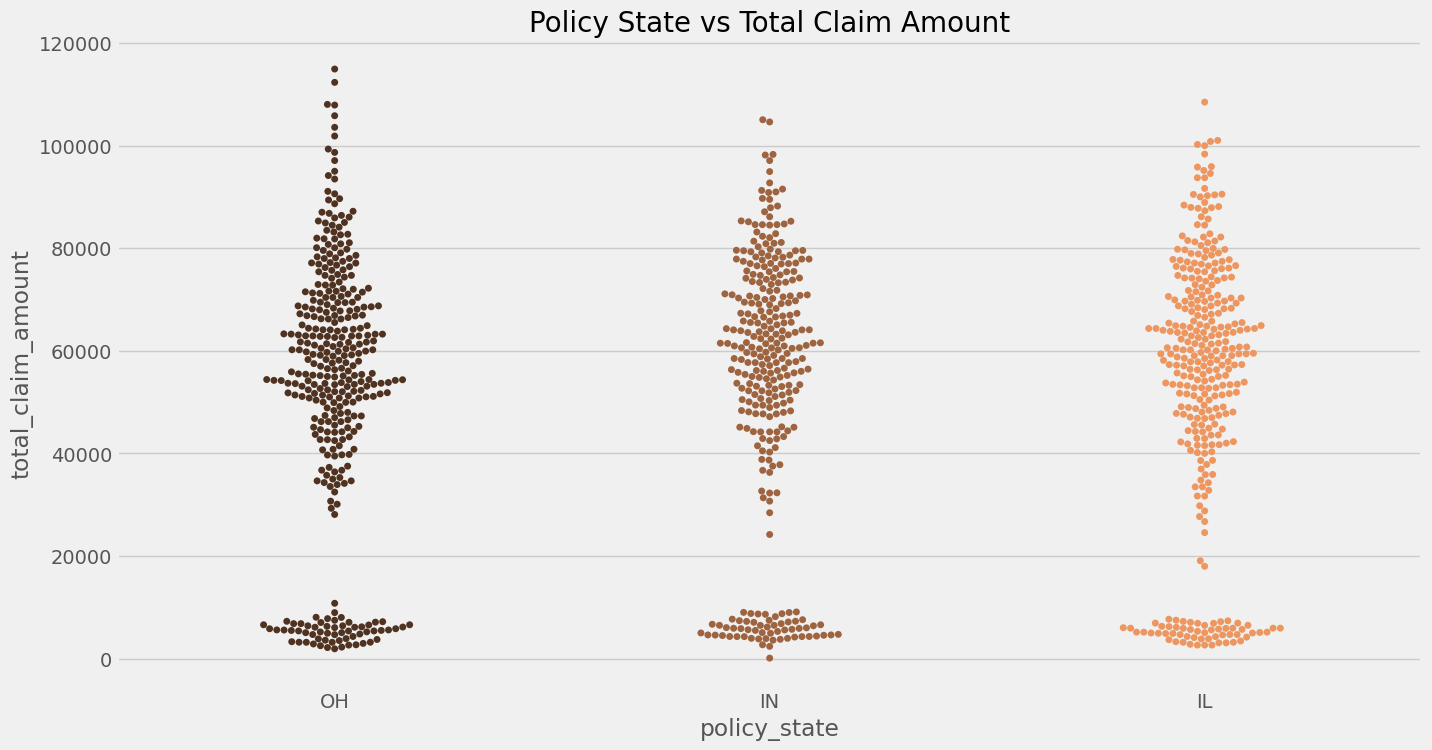

In [ ]:
plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 8)
sns.swarmplot(x=datos['policy_state'], y=datos['total_claim_amount'], palette =
'copper')
plt.title('Policy State vs Total Claim Amount', fontsize = 20)
plt.show()

**17.Realice el siguiente gráfico de pastel de la relación de insured_sex con reporte de
fraude**

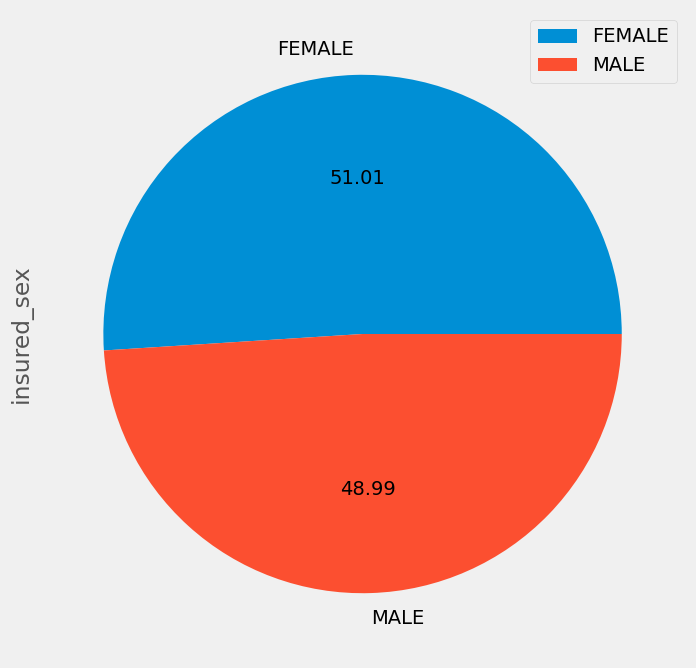

In [ ]:
X=datos.where(datos['fraud_reported']=='Y')
a=pd.DataFrame(X['insured_sex'].value_counts())
a.reset_index(inplace=True)
a.plot(kind='pie',y='insured_sex',labels=a['index'],autopct='%1.2f')
plt.show()

**18.Realice el grafico de pastel de la relación que existe entre el reporte de fraude con
las siguientes columnas:**

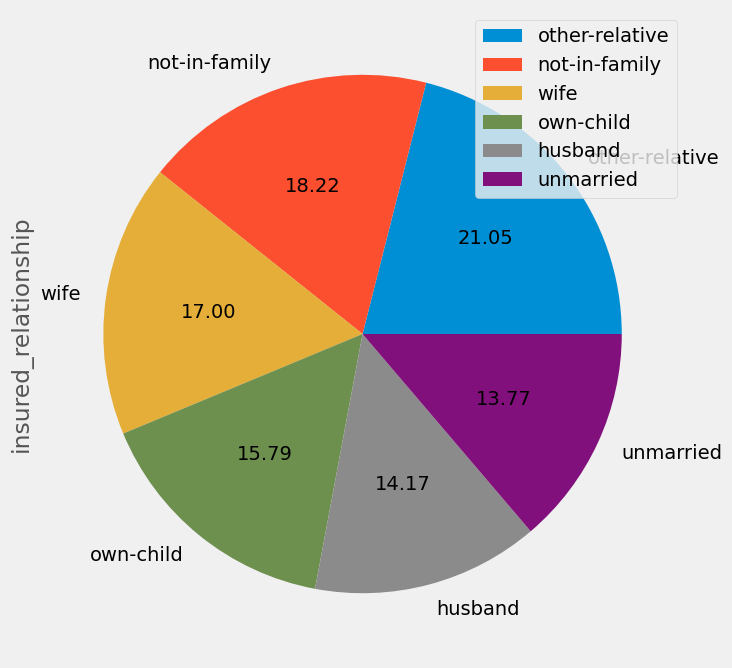

In [ ]:
#insured_relationship

X=datos.where(datos['fraud_reported']=='Y')
a=pd.DataFrame(X['insured_relationship'].value_counts())
a.reset_index(inplace=True)
a.plot(kind='pie',y='insured_relationship',labels=a['index'],autopct='%1.2f')
plt.show()

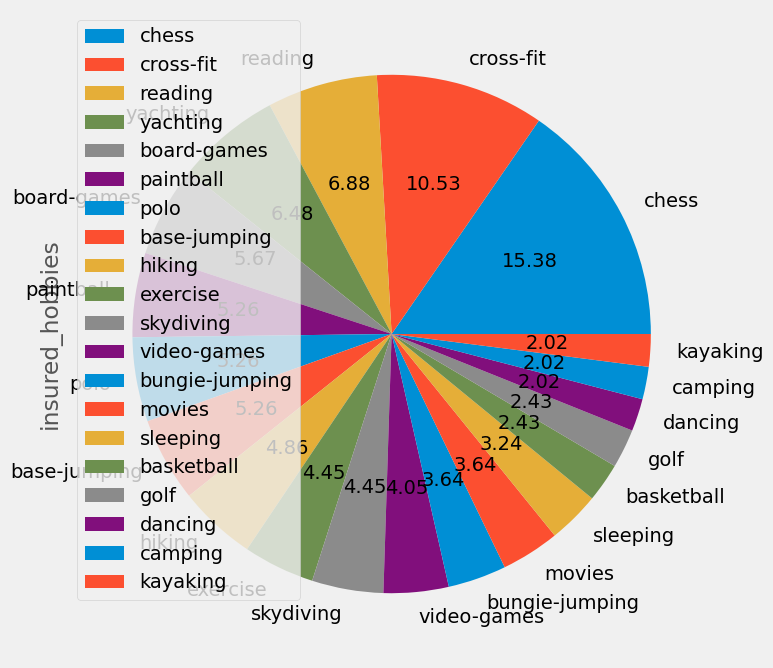

In [ ]:
#insured_hobbies
X=datos.where(datos['fraud_reported']=='Y')
a=pd.DataFrame(X['insured_hobbies'].value_counts())
a.reset_index(inplace=True)
a.plot(kind='pie',y='insured_hobbies',labels=a['index'],autopct='%1.2f')
plt.show()

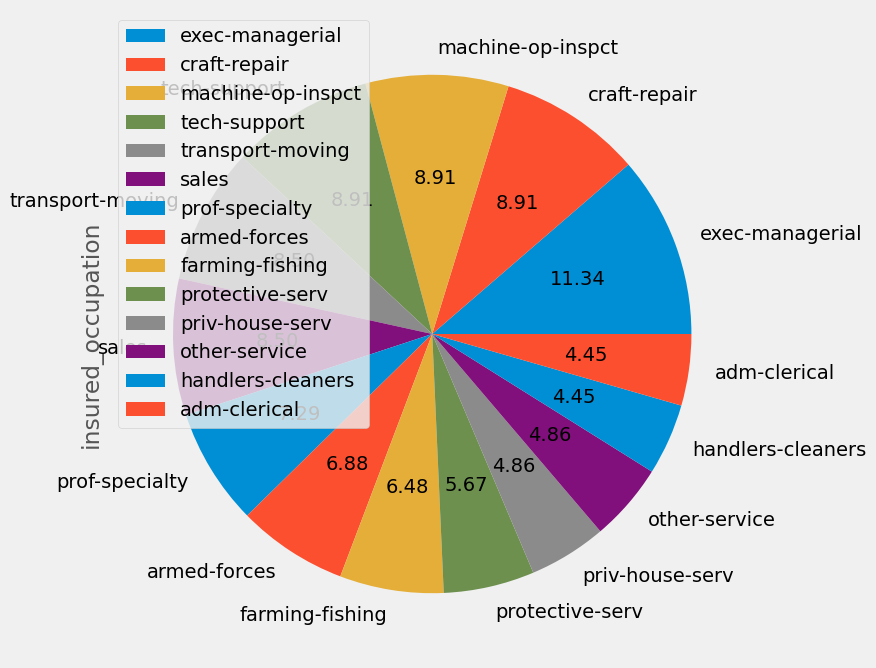

In [ ]:
#insured_occupation
X=datos.where(datos['fraud_reported']=='Y')
a=pd.DataFrame(X['insured_occupation'].value_counts())
a.reset_index(inplace=True)
a.plot(kind='pie',y='insured_occupation',labels=a['index'],autopct='%1.2f')
plt.show()

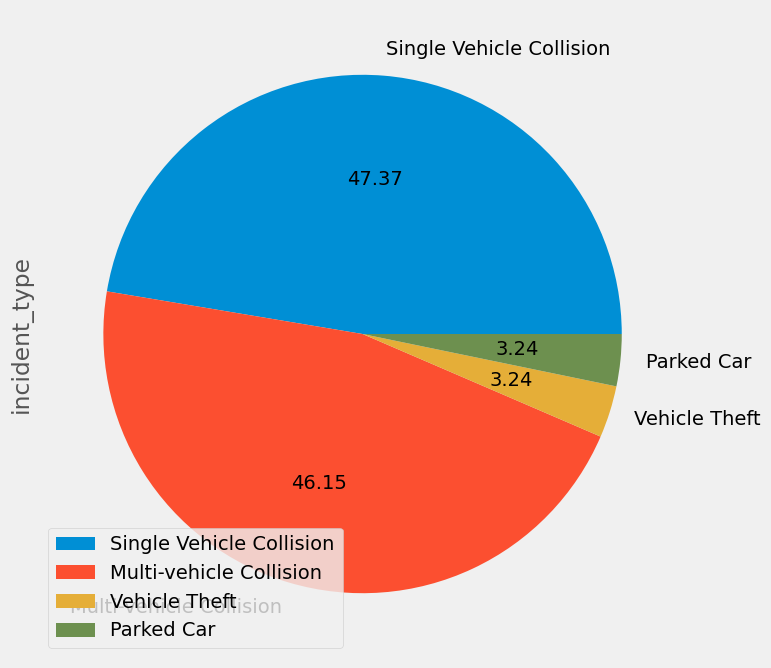

In [ ]:
#incident_type

X=datos.where(datos['fraud_reported']=='Y')
a=pd.DataFrame(X['incident_type'].value_counts())
a.reset_index(inplace=True)
a.plot(kind='pie',y='incident_type',labels=a['index'],autopct='%1.2f')
plt.show()

**19.Realice el siguiente diagrama de bigotes:**

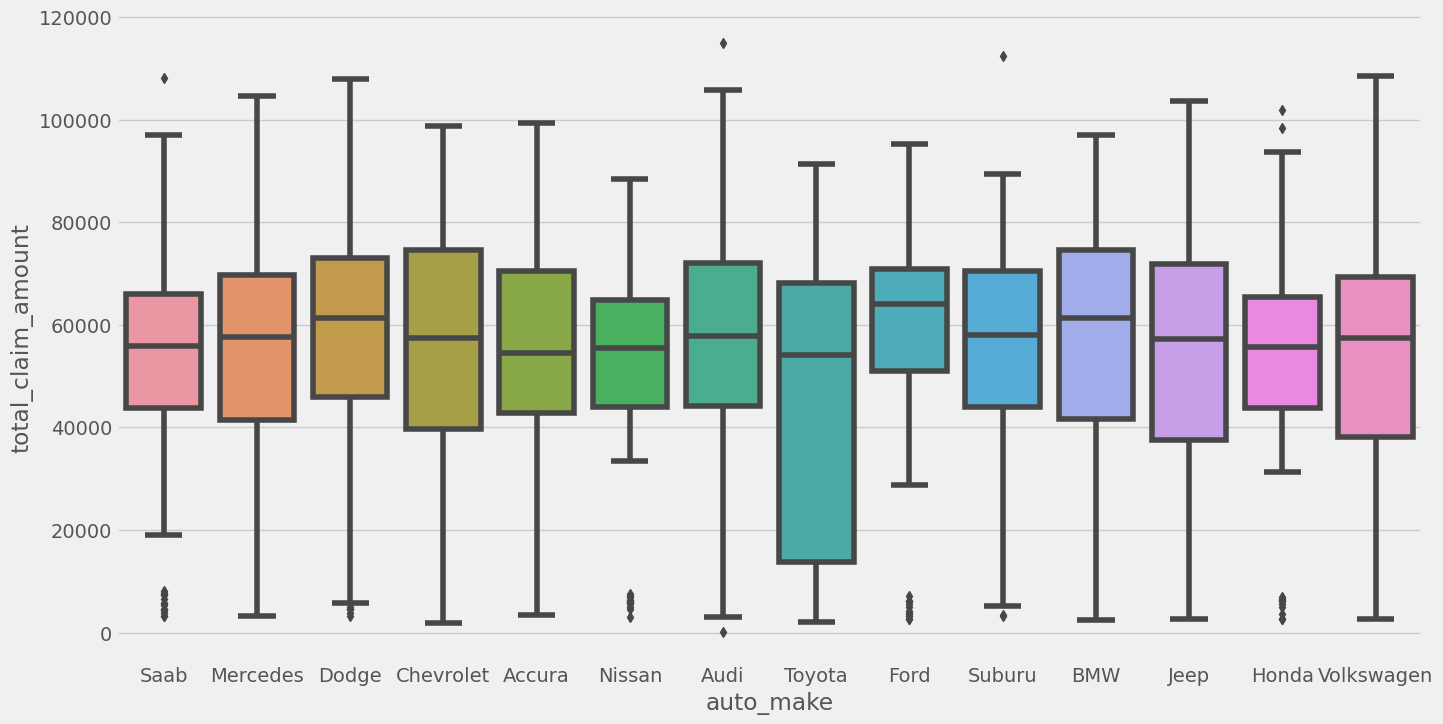

In [ ]:
sns.boxplot(x='auto_make',y='total_claim_amount',data=datos)
plt.show()

**20.Realice el diagrama de bigotes de months_as_customer**

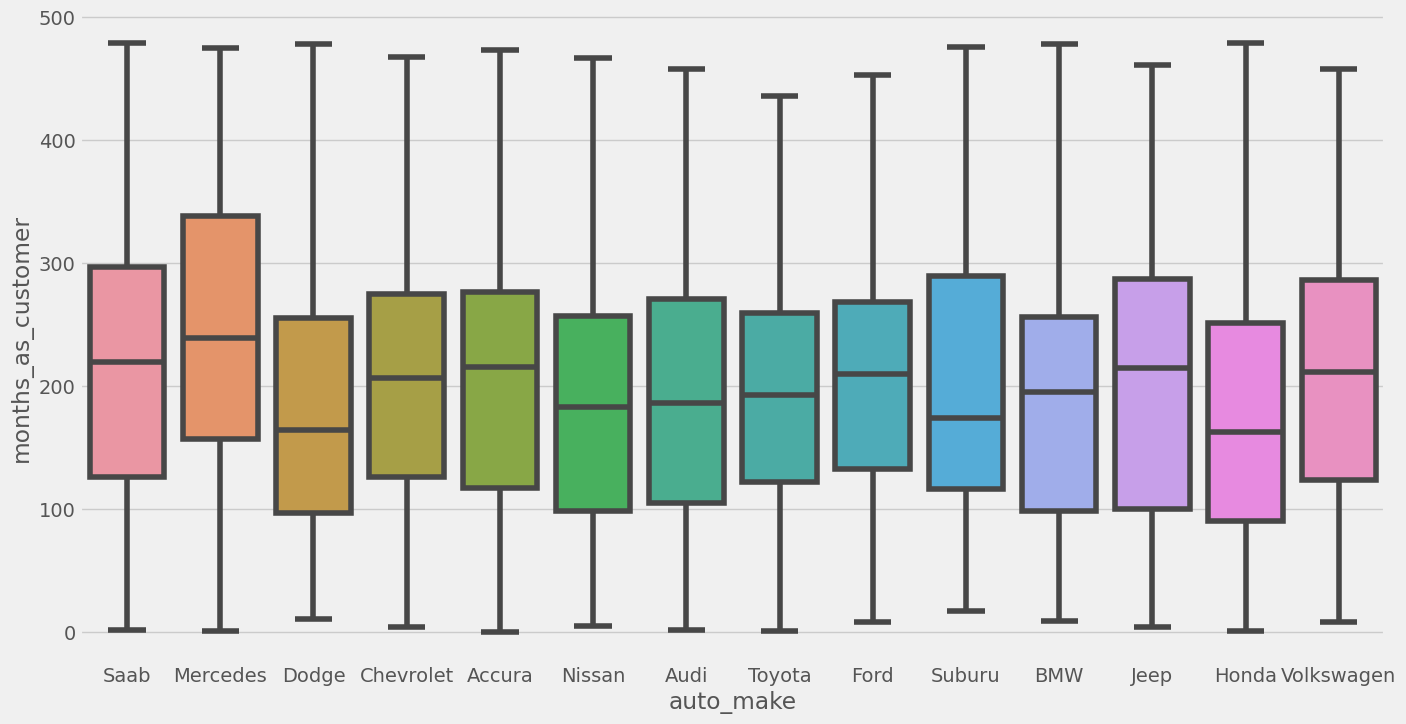

In [ ]:
sns.boxplot(x='auto_make',y='months_as_customer',data=datos)
plt.show()

**21.Realice los diagramas de distribución con el siguiente código:**

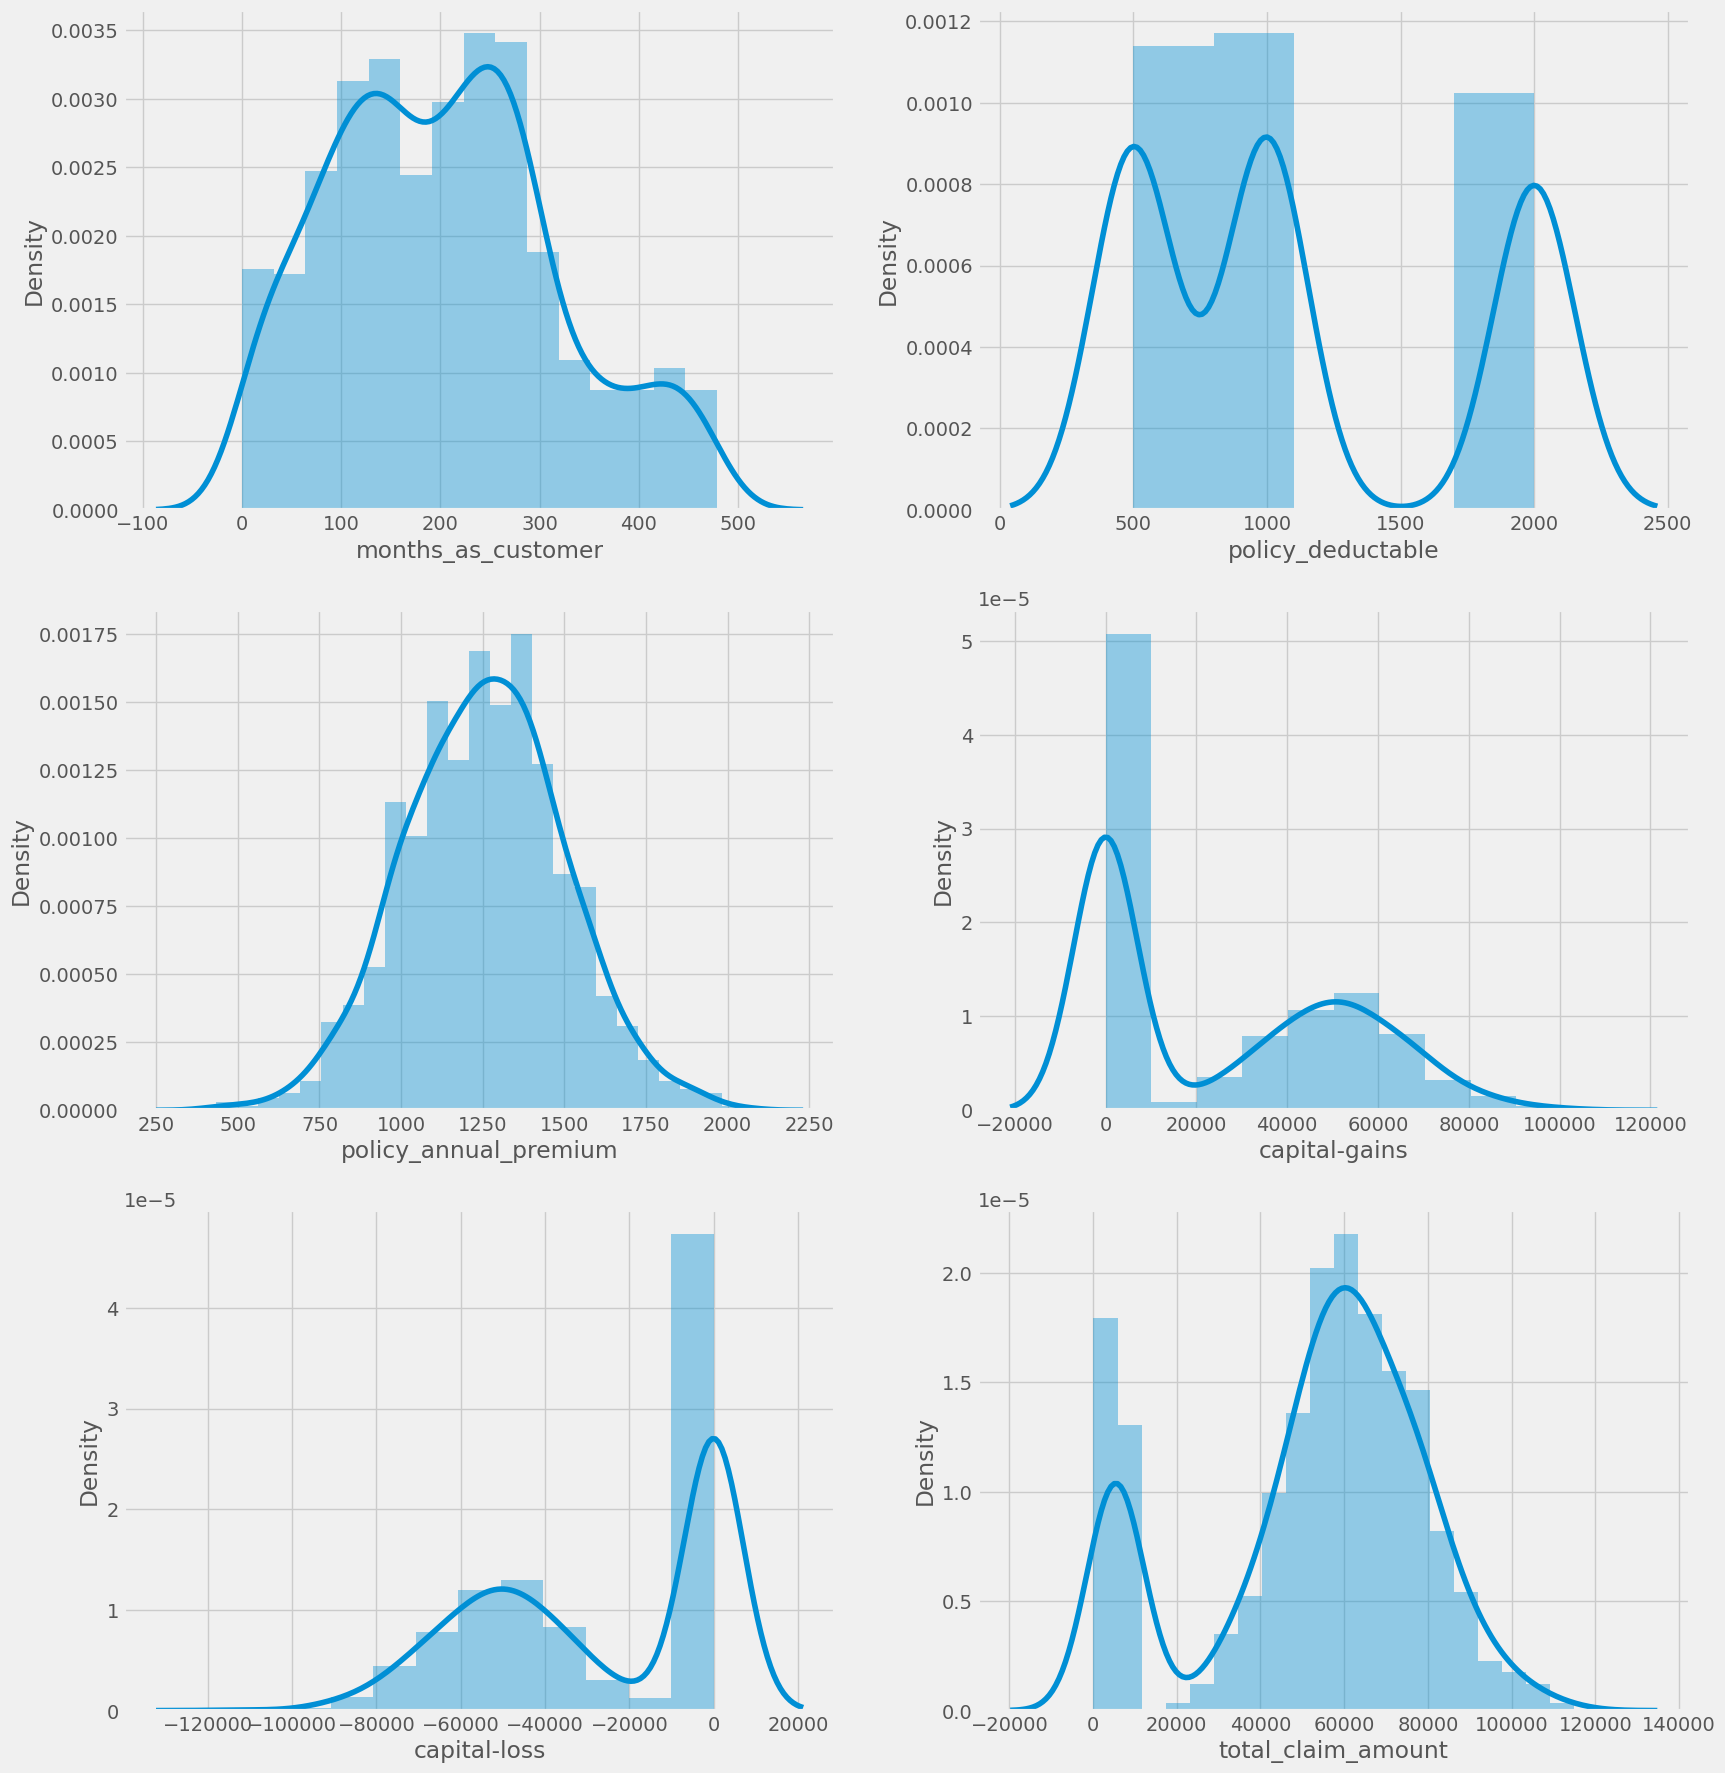

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
col=['months_as_customer','policy_deductable','policy_annual_premium','capital-gains','capital-loss','total_claim_amount']
plt.figure(figsize=(18,21))
k=1
for i in col :
 plt.subplot(3,2,k)
 sns.distplot(datos[i])
 k=k+1
plt.show()

**22.Obtenga el día del accidente de la columna incident_date con el siguiente código:**

In [ ]:
from datetime import date

def date_tonumberday(fecha):
 fecha = pd.to_datetime(fecha, errors = 'coerce')
 day_of_year = fecha.toordinal() - date(fecha.year, 1, 1).toordinal() + 1
 return day_of_year
datos['incident_day']=datos['incident_date'].apply(date_tonumberday)
datos.drop(columns=['incident_date'],axis=1,inplace=True)

**23.Codifique la variable objetivo con el siguiente código:**

In [ ]:
datos['fraud_reported'] = datos['fraud_reported'].replace(('N','Y'),(0,1))
datos['fraud_reported'].head()

0    1
1    1
2    0
3    1
4    0
Name: fraud_reported, dtype: int64

**24.Haga lo mismo con las columnas: police_report_available, property_damage
('NO'=0, 'Y'=1), insured_sex ('FEMALE'=0, 'MALE'=1), incident_severity ("Trivial
Damage"=0.1, "Minor Damage"=0.3, "Major Damage"=0.6, "Total Loss"=1.0),
insured_education_level ('High School'=0.63, 'College'=0.7, 'Associate'=0.78,
'Masters'=0.92, 'MD'=0.92, 'JD'=0.92, 'PhD'=1.0)**

In [ ]:
datos['police_report_available'] = datos['police_report_available'].replace(('NO','YES'),(0,1))
datos['property_damage'] = datos['property_damage'].replace(('NO','YES'),(0,1))
datos['insured_sex'] = datos['insured_sex'].replace(('FEMALE','MALE'),(0,1))
datos['incident_severity'] = datos['incident_severity'].replace(('Trivial Damage','Minor Damage', 'Major Damage', 'Total Loss'),(0.1,0.3,0.6,1.0))
datos['insured_education_level'] = datos['insured_education_level'].replace(('High School','College', 'Associate', 'Masters','MD','JD','PhD'),(0.63,0.7,0.78,0.92, 0.92,0.92,1.0))

**25.Codifique al formato One-hot la columna auto_make con el siguiente código:**

In [ ]:
cols = pd.get_dummies(datos.auto_make)
datos = pd.concat([datos.drop("auto_make",axis="columns"), cols], axis="columns")
datos.head()

,months_as_customer,policy_number,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,...,Dodge,Ford,Honda,Jeep,Mercedes,Nissan,Saab,Suburu,Toyota,Volkswagen
0,328,521585,OH,250/500,1000,1406.91,0,466132,1,0.92,...,0,0,0,0,0,0,1,0,0,0
1,228,342868,IN,250/500,2000,1197.22,5000000,468176,1,0.92,...,0,0,0,0,1,0,0,0,0,0
2,134,687698,OH,100/300,2000,1413.14,5000000,430632,0,1.00,...,1,0,0,0,0,0,0,0,0,0
3,256,227811,IL,250/500,2000,1415.74,6000000,608117,0,1.00,...,0,0,0,0,0,0,0,0,0,0
4,228,367455,IL,500/1000,1000,1583.91,6000000,610706,1,0.78,...,0,0,0,0,0,0,0,0,0,0


**26.Haga lo mismo con las columnas no ordinales: incident_city, policy_state,
authorities_contacted, collision_type, incident_type, insured_relationship,
insured_hobbies, insured_occupation y policy_csl.**

In [ ]:
cols = pd.get_dummies(datos.incident_city)
datos = pd.concat([datos.drop("incident_city",axis="columns"), cols], axis="columns")

cols = pd.get_dummies(datos.policy_state)
datos = pd.concat([datos.drop("policy_state",axis="columns"), cols], axis="columns")

cols = pd.get_dummies(datos.authorities_contacted)
datos = pd.concat([datos.drop("authorities_contacted",axis="columns"), cols], axis="columns")


cols = pd.get_dummies(datos.collision_type)
datos = pd.concat([datos.drop("collision_type",axis="columns"), cols], axis="columns")


cols = pd.get_dummies(datos.incident_type)
datos = pd.concat([datos.drop("incident_type",axis="columns"), cols], axis="columns")


cols = pd.get_dummies(datos.insured_relationship)
datos = pd.concat([datos.drop("insured_relationship",axis="columns"), cols], axis="columns")


cols = pd.get_dummies(datos.insured_hobbies)
datos= pd.concat([datos.drop("insured_hobbies",axis="columns"), cols], axis="columns")

cols = pd.get_dummies(datos.insured_occupation)
datos = pd.concat([datos.drop("insured_occupation",axis="columns"), cols], axis="columns")

cols = pd.get_dummies(datos.policy_csl)
datos = pd.concat([datos.drop("policy_csl",axis="columns"), cols], axis="columns")


datos.head()

,months_as_customer,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,capital-gains,capital-loss,...,other-service,priv-house-serv,prof-specialty,protective-serv,sales,tech-support,transport-moving,100/300,250/500,500/1000
0,328,521585,1000,1406.91,0,466132,1,0.92,53300,0,...,0,0,0,0,0,0,0,0,1,0
1,228,342868,2000,1197.22,5000000,468176,1,0.92,0,0,...,0,0,0,0,0,0,0,0,1,0
2,134,687698,2000,1413.14,5000000,430632,0,1.00,35100,0,...,0,0,0,0,1,0,0,1,0,0
3,256,227811,2000,1415.74,6000000,608117,0,1.00,48900,-62400,...,0,0,0,0,0,0,0,0,1,0
4,228,367455,1000,1583.91,6000000,610706,1,0.78,66000,-46000,...,0,0,0,0,1,0,0,0,0,1


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 100 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   policy_number                1000 non-null   int64  
 2   policy_deductable            1000 non-null   int64  
 3   policy_annual_premium        1000 non-null   float64
 4   umbrella_limit               1000 non-null   int64  
 5   insured_zip                  1000 non-null   int64  
 6   insured_sex                  1000 non-null   int64  
 7   insured_education_level      1000 non-null   float64
 8   capital-gains                1000 non-null   int64  
 9   capital-loss                 1000 non-null   int64  
 10  incident_severity            1000 non-null   float64
 11  incident_hour_of_the_day     1000 non-null   int64  
 12  number_of_vehicles_involved  1000 non-null   int64  
 13  property_damage   

**27.Normalice las columnas con MinMaxScaler.**

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(datos.to_numpy())
data_scaled = pd.DataFrame(data_scaled,columns=datos.columns)

**28.Separe las columnas independientes de la variable objetivo ('fraud_reported') en
X,Y**

In [ ]:
X = datos.drop(columns=['fraud_reported'])
# Y contendrá la columna de la variable objetivo
y = datos['fraud_reported']

**29.Use la función train_test_split para separar el conjunto de datos en 80%
entrenamiento y 20% prueba.**

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y.values.reshape(-1,1),
                                        train_size   = 0.8,
                                        random_state = 1234,
                                        shuffle      = True
                                    )


**30.Haga una búsqueda de la mejor configuración de hiper parámetros con
GridSearchCV para el Support Vector Machine con los siguientes parámetros:**

In [ ]:
param_grid = {'C':[15,17,19,21,23,25] , 'gamma':['scale',1/138,1/100,1/150,1/180]}
grid = GridSearchCV(
estimator = SVC(kernel= "rbf"),
 param_grid = param_grid,
 scoring = 'accuracy',
 n_jobs = -1,
 cv = 3,
 verbose = 0,
 return_train_score = True
 )
grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [15, 17, 19, 21, 23, 25],
                         'gamma': ['scale', 0.007246376811594203, 0.01,
                                   0.006666666666666667,
                                   0.005555555555555556]},
             return_train_score=True, scoring='accuracy')

**31.Muestre la mejor configuración encontrada.**

In [ ]:
print(grid.best_params_, ":", grid.best_score_, grid.scoring)

modelo = grid.best_estimator_

{'C': 15, 'gamma': 0.007246376811594203} : 0.767499272525884 accuracy


**32.Haga las predicciones del modelo con los datos de prueba y muestre la exactitud
del modelo.**

In [ ]:
# Predicciones test
# ==============================================================================
predicciones = modelo.predict(X_test)
predicciones

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0], dtype=int64)

In [ ]:
# Accuracy de test del modelo
# ==============================================================================
accuracy = accuracy_score(
            y_true    = y_test,
            y_pred    = predicciones,
            normalize = True
           )
print("")
print(f"El accuracy de test es: {100*accuracy}%")


El accuracy de test es: 69.5%


**33.Muestre la matriz de confusión del modelo**

In [ ]:
#Predecimos el test y utilizamos métricas de clasificacion para comprobar nuestros modelos en Train
preds_test = modelo.predict(X_test)
print('CLASSIFICATION IN TRAIN')
print("----------------------------------------")
print('CONFUSION MATRIX:\n', confusion_matrix(preds_test, y_test))
print("----------------------------------------")
#print('F1 SCORE:\n', f1_score(preds_test, Ytest))
print("----------------------------------------")
print('CLASSIFICATION REPORT\n',classification_report(preds_test, y_test))

CLASSIFICATION IN TRAIN
----------------------------------------
CONFUSION MATRIX:
 [[139  61]
 [  0   0]]
----------------------------------------
----------------------------------------
CLASSIFICATION REPORT
               precision    recall  f1-score   support

           0       1.00      0.69      0.82       200
           1       0.00      0.00      0.00         0

    accuracy                           0.69       200
   macro avg       0.50      0.35      0.41       200
weighted avg       1.00      0.69      0.82       200



**34.Indique las dimensiones de los vectores de soporte del modelo
(modelo.support_vectors_.shape)**

In [ ]:
modelo.support_vectors_.shape

(800, 99)

**35.Repita los pasos 30-34 pero ahora con los siguientes parámetros:<br>
Kernel 'linear'<br>
'C':[0.08,0.09,0.1,0.11,0.12]<br>
Mismo gamma<br>
Kernel sigmoide 'sigmoid'<br>
'C': np.logspace(0, 2, 20)<br>
Mismo gamma<br>**

In [ ]:
param_grid = {'C':[0.08,0.09],
 'gamma':['scale',1/138,1/100,1/150]}
grid = GridSearchCV(
estimator = SVC(kernel= "linear"),
 param_grid = param_grid,
 scoring = 'accuracy',
 n_jobs = -1,
 cv = 3,
 verbose = 0,
 return_train_score = True
 )
grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=SVC(kernel='linear'), n_jobs=-1,
             param_grid={'C': [0.08, 0.09],
                         'gamma': ['scale', 0.007246376811594203, 0.01,
                                   0.006666666666666667]},
             return_train_score=True, scoring='accuracy')

In [ ]:
print(grid.best_params_, ":", grid.best_score_, grid.scoring)

modelolinear = grid.best_estimator_

{'C': 0.09, 'gamma': 'scale'} : 0.7424460026470671 accuracy


In [ ]:
# Predicciones test
# ==============================================================================
predicciones = modelolinear.predict(X_test)
predicciones

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0], dtype=int64)

In [ ]:
# Accuracy de test del modelo
# ==============================================================================
accuracy = accuracy_score(
            y_true    = y_test,
            y_pred    = predicciones,
            normalize = True
           )
print("")
print(f"El accuracy de test es: {100*accuracy}%")


El accuracy de test es: 67.0%


In [ ]:
#Predecimos el test y utilizamos métricas de clasificacion para comprobar nuestros modelos en Train
preds_test = modelo.predict(X_test)
print('CLASSIFICATION IN TRAIN')
print("----------------------------------------")
print('CONFUSION MATRIX:\n', confusion_matrix(preds_test, y_test))
print("----------------------------------------")
#print('F1 SCORE:\n', f1_score(preds_test, Ytest))
print("----------------------------------------")
print('CLASSIFICATION REPORT\n',classification_report(preds_test, y_test))

CLASSIFICATION IN TRAIN
----------------------------------------
CONFUSION MATRIX:
 [[139  61]
 [  0   0]]
----------------------------------------
----------------------------------------
CLASSIFICATION REPORT
               precision    recall  f1-score   support

           0       1.00      0.69      0.82       200
           1       0.00      0.00      0.00         0

    accuracy                           0.69       200
   macro avg       0.50      0.35      0.41       200
weighted avg       1.00      0.69      0.82       200



In [ ]:
param_grid = {'C':[500,550,600],
'degree':[3,4],
'gamma':['scale',1/138,1/100]}
grid = GridSearchCV(
estimator = SVC(kernel= "poly"),
 param_grid = param_grid,
 scoring = 'accuracy',
 n_jobs = -1,
 cv = 3,
 verbose = 0,
 return_train_score = True
 )
grid.fit(X_train, y_train)

In [ ]:
print(grid.best_params_, ":", grid.best_score_, grid.scoring)

modelolinear = grid.best_estimator_

In [ ]:
# Predicciones test
# ==============================================================================
predicciones = modelopoly.predict(X_test)
predicciones

In [ ]:
# Accuracy de test del modelo
# ==============================================================================
accuracy = accuracy_score(
            y_true    = y_test,
            y_pred    = predicciones,
            normalize = True
           )
print("")
print(f"El accuracy de test es: {100*accuracy}%")

In [ ]:
#Predecimos el test y utilizamos métricas de clasificacion para comprobar nuestros modelos en Train
preds_test = modelo.predict(X_test)
print('CLASSIFICATION IN TRAIN')
print("----------------------------------------")
print('CONFUSION MATRIX:\n', confusion_matrix(preds_test, y_test))
print("----------------------------------------")
#print('F1 SCORE:\n', f1_score(preds_test, Ytest))
print("----------------------------------------")
print('CLASSIFICATION REPORT\n',classification_report(preds_test, y_test))

In [ ]:
param_grid = {'C':[20,22],
 'gamma':['scale',1/138,1/100]}
grid = GridSearchCV(
estimator = SVC(kernel= "sigmoid"),
 param_grid = param_grid,
 scoring = 'accuracy',
 n_jobs = -1,
 cv = 3,
 verbose = 0,
 return_train_score = True
 )
grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=SVC(kernel='sigmoid'), n_jobs=-1,
             param_grid={'C': [20, 22],
                         'gamma': ['scale', 0.007246376811594203, 0.01]},
             return_train_score=True, scoring='accuracy')

In [ ]:
print(grid.best_params_, ":", grid.best_score_, grid.scoring)

modelosig = grid.best_estimator_

{'C': 20, 'gamma': 'scale'} : 0.7524710653037087 accuracy


In [ ]:
# Predicciones test
# ==============================================================================
predicciones = modelosig.predict(X_test)
predicciones

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0], dtype=int64)

In [ ]:
# Accuracy de test del modelo
# ==============================================================================
accuracy = accuracy_score(
            y_true    = y_test,
            y_pred    = predicciones,
            normalize = True
           )
print("")
print(f"El accuracy de test es: {100*accuracy}%")


El accuracy de test es: 68.0%


In [ ]:
#Predecimos el test y utilizamos métricas de clasificacion para comprobar nuestros modelos en Train
preds_test = modelo.predict(X_test)
print('CLASSIFICATION IN TRAIN')
print("----------------------------------------")
print('CONFUSION MATRIX:\n', confusion_matrix(preds_test, y_test))
print("----------------------------------------")
#print('F1 SCORE:\n', f1_score(preds_test, Ytest))
print("----------------------------------------")
print('CLASSIFICATION REPORT\n',classification_report(preds_test, y_test))

CLASSIFICATION IN TRAIN
----------------------------------------
CONFUSION MATRIX:
 [[139  61]
 [  0   0]]
----------------------------------------
----------------------------------------
CLASSIFICATION REPORT
               precision    recall  f1-score   support

           0       1.00      0.69      0.82       200
           1       0.00      0.00      0.00         0

    accuracy                           0.69       200
   macro avg       0.50      0.35      0.41       200
weighted avg       1.00      0.69      0.82       200



**36.En un Excel que adjunte o una tabla html de jupyter-lab registre los mejores
resultados de cada configuración.**

<table>
  <tr style="text-align: center;font-weight: bold;">
    <td style="text-align: center;">Kernel</td>
    <td style="text-align: center;font-weight: bold;">Valor C</td>
    <td style="text-align: center;font-weight: bold;">Valor Gamma</td>
    <td style="text-align: center;font-weight: bold;">% exactitud</td>
  </tr>
  <tr>
    <td>Rbf</td><td>15</td><td>0.00724</td><td>0.7674</td>
      </tr>
    <tr>
     <td>Lineal</td><td>0.09</td><td>0.7424</td><td>0.67</td>
      </tr>
    <tr>
     <td>Polinomial</td><td>-</td><td>-</td><td>-</td>
      </tr>
    <tr>
     <td>Sigmoide</td><td>20</td><td>0.75</td><td>0.68</td>
      </tr>
</table>